<a href="https://colab.research.google.com/github/akhilrattan/machine-learning/blob/main/research_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from skimage.feature import graycomatrix, graycoprops

In [11]:
!rm -rf /content/drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
dataset_path = "/content/drive/MyDrive/Research_Assignment/RealWaste"

In [14]:
import os

classes = sorted(os.listdir(dataset_path))

print("Classes:")
for cls in classes:
    print(cls)

Classes:
Cardboard
Food Organics
Glass
Metal
Miscellaneous Trash
Paper
Plastic
Textile Trash
Vegetation


In [15]:
total = 0

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    total += count
    print(f"{cls:25} : {count}")

print(f"\nTotal Images: {total}")

Cardboard                 : 461
Food Organics             : 411
Glass                     : 420
Metal                     : 790
Miscellaneous Trash       : 495
Paper                     : 500
Plastic                   : 921
Textile Trash             : 318
Vegetation                : 436

Total Images: 4752


In [16]:
IMG_SIZE = (128, 128)

images = []
labels = []

for label, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_path):

        img_path = os.path.join(class_path, file)

        image = cv2.imread(img_path)

        if image is None:
            continue

        image = cv2.resize(image, IMG_SIZE)

        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)


Images Shape : (4752, 128, 128, 3)
Labels Shape : (4752,)


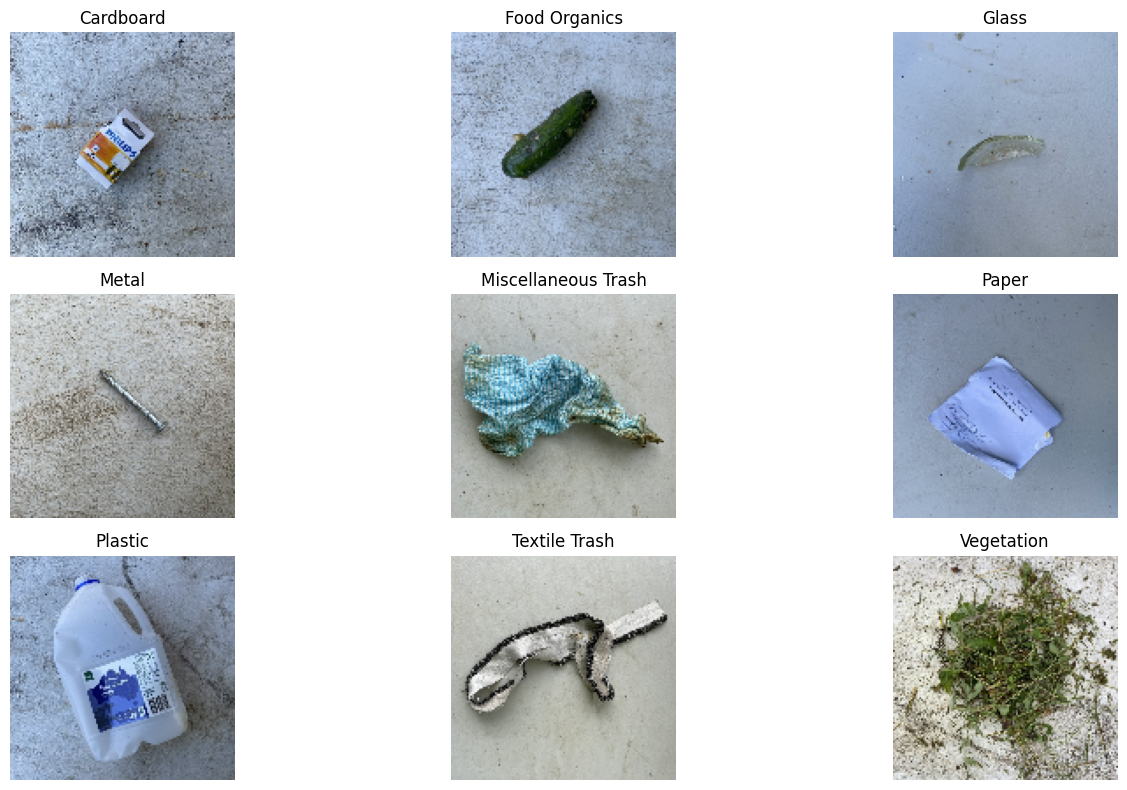

In [17]:
plt.figure(figsize=(15,8))

for i, class_name in enumerate(classes):

    index = np.where(labels == i)[0][0]

    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import os
output_path = "/content/drive/MyDrive/Research_Assignment"

original_path = os.path.join(output_path, "Original")

os.makedirs(original_path, exist_ok=True)

for class_name in classes:
    os.makedirs(os.path.join(original_path, class_name), exist_ok=True)

count = [0] * len(classes)

for image, label in zip(images, labels):

    class_name = classes[label]

    filename = f"{count[label]}.jpg"

    save_path = os.path.join(original_path, class_name, filename)

    cv2.imwrite(save_path, image)

    count[label] += 1

print("Original dataset created successfully!")

NameError: name 'classes' is not defined

In [18]:
quality_path = os.path.join(output_path,"Quality Degradation")

os.makedirs(output_path, exist_ok = True)
for class_name in classes:
    os.makedirs(os.path.join(quality_path, class_name), exist_ok = True)

count = [0] * len(classes)

for image, label in zip(images, labels):
    image = image.astype(np.float32)
    noise = np.random.normal(loc = 0, scale = 25, size = image.shape)
    noisy = image + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    degraded = cv2.GaussianBlur(noisy, (5,5), 0)
    class_name = classes[label]
    filename = f"{count[label]}.jpg"
    save_path = os.path.join(quality_path, class_name, filename)
    cv2.imwrite(save_path, degraded)
    count[label] += 1

print("Quality degradation dataset created successfully!")


Quality degradation dataset created successfully!


In [21]:
illumination_path = os.path.join(output_path, "Illumination Variation")

os.makedirs(illumination_path, exist_ok=True)

for class_name in classes:
    os.makedirs(os.path.join(illumination_path, class_name), exist_ok=True)

count = [0]*len(classes)

for image, label in zip(images, labels):
    if np.random.rand() < 0.5:
        output = cv2.convertScaleAbs(image, alpha=0.5, beta=0)
    else:
        output = cv2.convertScaleAbs(image, alpha =1.5, beta=0)
    class_name =classes[label]
    file_name =f"{count[label]}.jpg"
    save_path = os.path.join(illumination_path, class_name, file_name)
    cv2.imwrite(save_path, output)
    count[label] += 1
print("Illumination variation dataset created successfully!")

Illumination variation dataset created successfully!


In [22]:
def extract_color_histogram(image):
  features = []

  for channel in range(3):
      hist = cv2.calcHist([images], [channel], None, [256], [0,256])
      features.extend(hist.flatten())
      features.extend(hist.flatten())
      return features


In [23]:
def extract_edge_density(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 100, 200)

    edge_pixels = np.sum(edges > 0)

    total_pixels = edges.shape[0] * edges.shape[1]

    edge_density = edge_pixels / total_pixels

    return [edge_density]

In [24]:
def extract_texture_features(image):

    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Mean Intensity
    mean = np.mean(gray)

    # Standard Deviation
    std = np.std(gray)

    # Histogram
    hist = cv2.calcHist([gray], [0], None, [256], [0,256])

    # Normalize histogram
    hist = hist.ravel() / hist.sum()

    # Entropy
    entropy = -np.sum(hist * np.log2(hist + 1e-10))

    # Contrast
    contrast = np.max(gray) - np.min(gray)

    return [mean, std, entropy, contrast]

In [25]:
def extract_features(image):

    # RGB Histogram (48 features)
    color_features = extract_color_histogram(image)

    # Edge Density (1 feature)
    edge_feature = extract_edge_density(image)

    # Texture Features (4 features)
    texture_features = extract_texture_features(image)

    # Combine all features
    feature_vector = np.concatenate([
        color_features,
        edge_feature,
        texture_features
    ])

    return feature_vector

In [26]:
def create_feature_dataset(dataset_path):

    X = []
    y = []

    classes = sorted([
        folder for folder in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, folder))
    ])

    for label, class_name in enumerate(classes):

        class_path = os.path.join(dataset_path, class_name)

        for file in os.listdir(class_path):

            image_path = os.path.join(class_path, file)

            image = cv2.imread(image_path)

            if image is None:
                continue

            features = extract_features(image)

            X.append(features)

            y.append(label)

    return np.array(X), np.array(y)

In [29]:
X_original, y_original = create_feature_dataset(original_path)

print(X_original.shape)
print(y_original.shape)
X_quality, y_quality = create_feature_dataset(quality_path)

print(X_quality.shape)
X_illumination, y_illumination = create_feature_dataset(illumination_path)

print(X_illumination.shape)

(4752, 517)
(4752,)
(4752, 517)
(4752, 517)


In [30]:
scaler_original = StandardScaler()

X_original = scaler_original.fit_transform(X_original)

scaler_quality = StandardScaler()

X_quality = scaler_quality.fit_transform(X_quality)

scaler_illumination = StandardScaler()

X_illumination = scaler_illumination.fit_transform(X_illumination)

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=42,
    stratify=y_original
)
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_quality,
    y_quality,
    test_size=0.2,
    random_state=42,
    stratify=y_quality
)
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_illumination,
    y_illumination,
    test_size=0.2,
    random_state=42,
    stratify=y_illumination
)

In [31]:
svm_original = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    random_state=42
)

svm_original.fit(X_train_o, y_train_o)
svm_quality = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    random_state=42
)

svm_quality.fit(X_train_q, y_train_q)
svm_illumination = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    random_state=42
)

svm_illumination.fit(X_train_i, y_train_i)


SVC(C=1, random_state=42)

In [32]:
y_pred_o = svm_original.predict(X_test_o)
y_pred_q = svm_quality.predict(X_test_q)
y_pred_i = svm_illumination.predict(X_test_i)

In [33]:
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, cm

acc_o, pre_o, rec_o, f1_o, cm_o = evaluate_model(
    y_test_o,
    y_pred_o
)
acc_q, pre_q, rec_q, f1_q, cm_q = evaluate_model(
    y_test_q,
    y_pred_q
)
acc_i, pre_i, rec_i, f1_i, cm_i = evaluate_model(
    y_test_i,
    y_pred_i
)

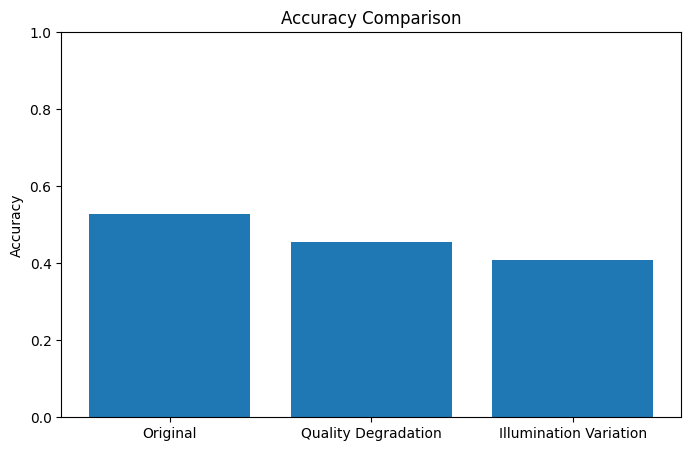

In [34]:
results = pd.DataFrame({

    "Dataset":[
        "Original",
        "Quality Degradation",
        "Illumination Variation"
    ],

    "Accuracy":[
        acc_o,
        acc_q,
        acc_i
    ],

    "Precision":[
        pre_o,
        pre_q,
        pre_i
    ],

    "Recall":[
        rec_o,
        rec_q,
        rec_i
    ],

    "F1-Score":[
        f1_o,
        f1_q,
        f1_i
    ]

})

results
plt.figure(figsize=(8,5))

plt.bar(
    results["Dataset"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

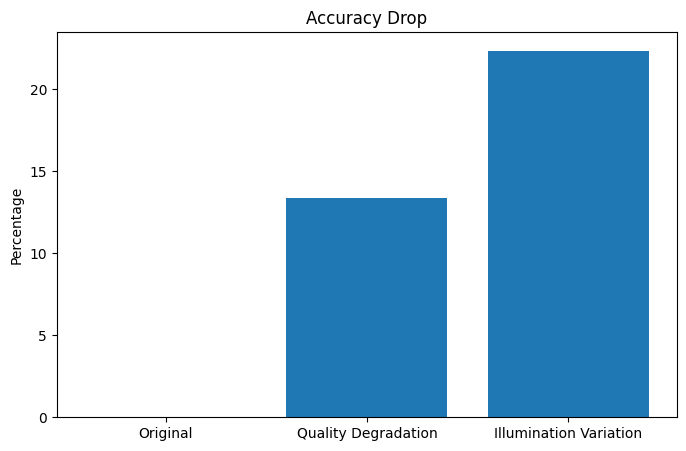

In [35]:
results["Accuracy Drop (%)"] = (
    (acc_o - results["Accuracy"]) / acc_o
) * 100

results

plt.figure(figsize=(8,5))

plt.bar(
    results["Dataset"],
    results["Accuracy Drop (%)"]
)

plt.title("Accuracy Drop")

plt.ylabel("Percentage")

plt.show()

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

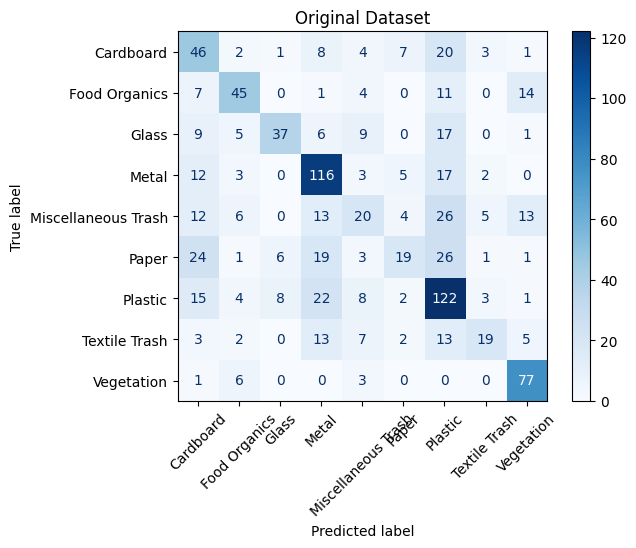

In [38]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_o,
    display_labels=classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Original Dataset")

plt.show()

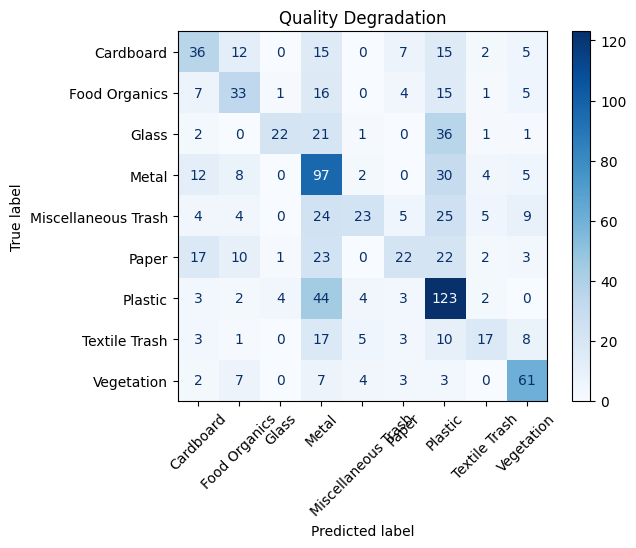

In [39]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_q,
    display_labels=classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Quality Degradation")

plt.show()

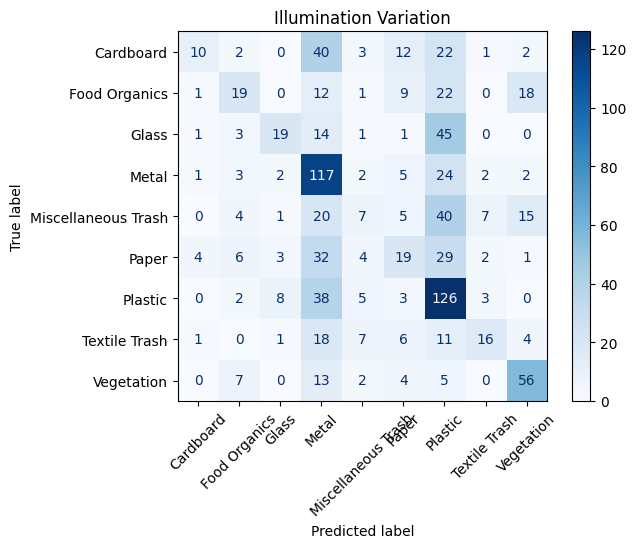

In [40]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_i,
    display_labels=classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Illumination Variation")

plt.show()